# Kernel density with misah

A density estimate answers one question: *how many observations per unit
volume are there, here?* Hypocentres per cubic kilometre, faults per square
kilometre, earthquakes per kilometre of depth.

It is worth being clear about what that is not. It is not a count, and it is
not a heat map with arbitrary units. If the estimate is done properly the field
integrates back to the number of observations, which means two runs at
different bandwidths, on different grids, in different studies, are comparable
with each other. Everything in this notebook follows from insisting on that.

The estimator is generic over the dimension. `misah` will give you a density
along a line, over a map, or through a volume with the same call — the
dimension is read off the width of the array you hand it.

Everything below runs on synthetic data generated in the notebook, so you can
execute it end to end without any files.

## Some hypocentres

Two clusters at different depths, which is the case that will keep coming back:
a shallow one and a deeper one, in a seismogenic layer that is far wider than
it is thick.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from misah.kernels import covering_grid, density_field, kernel_profile

rng = np.random.default_rng(20260907)

# Metres, in some projected CRS. A shallow cluster and a deeper one, plus a
# scatter of background seismicity across the whole volume.
shallow = rng.normal([8_000, 12_000, -4_000], [1_200, 1_200, 700], size=(400, 3))
deep    = rng.normal([16_000, 9_000, -11_000], [1_800, 1_800, 900], size=(300, 3))
spread  = rng.uniform([2_000, 3_000, -14_000], [22_000, 18_000, -2_000], size=(150, 3))

hypocentres = np.vstack([shallow, deep, spread])

print(f"{len(hypocentres)} hypocentres")
print("easting  ", hypocentres[:, 0].min(), "to", hypocentres[:, 0].max())
print("northing ", hypocentres[:, 1].min(), "to", hypocentres[:, 1].max())
print("depth    ", hypocentres[:, 2].min(), "to", hypocentres[:, 2].max())

850 hypocentres
easting   2078.7769369549605 to 21863.676386633204
northing  3025.8430617917597 to 17970.82396751325
depth     -13941.116538895112 to -2011.5822186902697


## The grid, and the half-cell that isn't there

`covering_grid` builds a grid around the data. It returns `origin`, `spacing`
and `counts` — and the important thing about it is that **`origin` is the first
sample point**, not the corner of a cell around it.

That sounds pedantic until it costs you half a cell. A raster header saying
`ORIGIN` may mean either, and code that declares one while computing the other
produces a field displaced by half a spacing in every direction — shifted
rather than wrong-looking, and so survivable for years. There are no cells here
to be ambiguous about. `counts` is the number of *nodes* along each axis, one
more than the number of intervals.

`margin` extends the grid past the outermost observation. About one bandwidth
is the useful choice: it is where a compact kernel has finished falling away,
so you see the whole of the decay instead of a field chopped off mid-slope.

In [2]:
BANDWIDTH = 1_500.0   # metres, for now isotropic

grid = covering_grid(hypocentres, spacing=[500.0, 500.0, 500.0], margin=BANDWIDTH)

for key, value in grid.items():
    print(f"{key:12} {value}")

# The origin sits exactly one margin below the lowest observation on each axis.
print()
print("origin - (data minimum - margin) =",
      np.array(grid["origin"]) - (hypocentres.min(axis=0) - BANDWIDTH))

origin       [578.7769369549605, 1525.8430617917597, -15441.116538895112]
spacing      [500.0, 500.0, 500.0]
counts       [46, 36, 30]
node_count   49680

origin - (data minimum - margin) = [0. 0. 0.]


## The field

`density_field` evaluates the estimate at every node. The value is
**observations per unit volume** — here, hypocentres per cubic metre, which is
a very small number in SI and exactly the right one.

The test that it means what it says: sum the field over the grid, multiply by
the cell volume, and you should get the number of hypocentres back.

In [3]:
values = density_field(
    hypocentres,
    origin=grid["origin"],
    spacing=grid["spacing"],
    counts=grid["counts"],
    bandwidth=[BANDWIDTH] * 3,
    kernel="quartic",
)

cell_volume = float(np.prod(grid["spacing"]))
recovered = values.sum() * cell_volume

print(f"{values.shape[0]} nodes")
print(f"peak density      {values.max():.3e} hypocentres/m^3")
print(f"integrates to     {recovered:.2f}")
print(f"hypocentres given {len(hypocentres)}")

49680 nodes
peak density      1.916e-08 hypocentres/m^3
integrates to     850.11
hypocentres given 850


That last pair is the whole point. The residual is quadrature error — the
grid is a Riemann sum of a smooth function — and it shrinks as the grid is
refined. It does **not** shrink if the normalizing constant is wrong, and a
constant that is right in two dimensions is wrong by a factor in three. That is
the mistake the C++ program this estimator descends from actually made, which
is why the check is a one-liner here rather than a footnote.

## Flat order, and the reshape

The field comes back flat, in the grid's own order: **first axis fastest**. x
runs, then y, then z. That is the order a VTK `STRUCTURED_POINTS` file wants,
which is not a coincidence.

It is not reshaped for you, because the reshape is exactly where the convention
would go unsaid. Ask numpy for it explicitly:

volume (46, 36, 30)


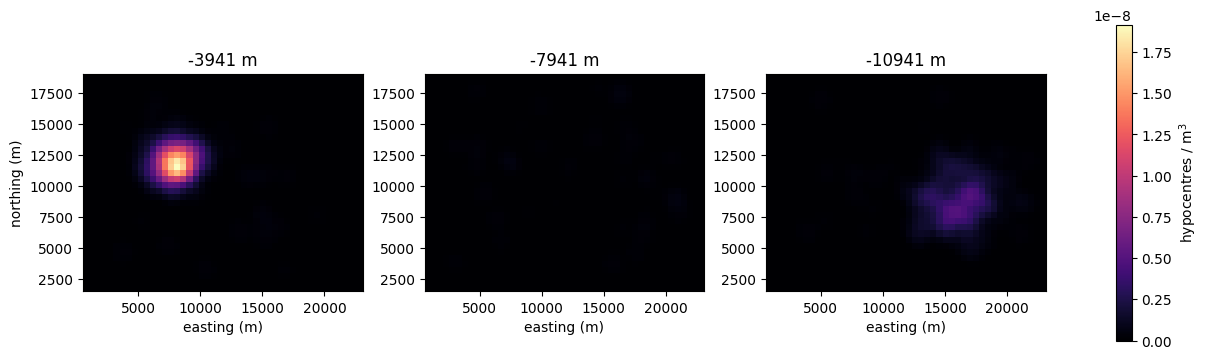

In [4]:
volume = values.reshape(grid["counts"], order="F")     # volume[i, j, k]
print("volume", volume.shape)

# Depth of each layer of nodes, for labelling.
depths = grid["origin"][2] + np.arange(grid["counts"][2]) * grid["spacing"][2]

# Three horizontal slices through the volume.
wanted = [-4_000, -8_000, -11_000]
layers = [int(np.argmin(np.abs(depths - d))) for d in wanted]

extent = [
    grid["origin"][0],
    grid["origin"][0] + (grid["counts"][0] - 1) * grid["spacing"][0],
    grid["origin"][1],
    grid["origin"][1] + (grid["counts"][1] - 1) * grid["spacing"][1],
]

fig, axes = plt.subplots(1, 3, figsize=(12, 3.8), constrained_layout=True)
for ax, layer in zip(axes, layers):
    im = ax.imshow(volume[:, :, layer].T, origin="lower", extent=extent,
                   cmap="magma", vmin=0, vmax=volume.max())
    ax.set_title(f"{depths[layer]:.0f} m")
    ax.set_xlabel("easting (m)")
axes[0].set_ylabel("northing (m)")
fig.colorbar(im, ax=axes, label="hypocentres / m$^3$", shrink=0.85)
plt.show()

The shallow cluster shows at 4 km and the deep one at 11 km, as they
should. Note `.T` in the plot: `imshow` wants row-major, and `volume` is
indexed `[easting, northing, depth]`.

## Bandwidth is the choice that matters

It is also the one no data can make for you. Too small and the field is a set
of bumps, one per observation, reporting sampling noise as structure. Too large
and two clusters merge into one and the map says there is a single anomaly
where there are two.

The bandwidth is in **map units**, not in cells. A bandwidth expressed in cells
changes meaning when you refine the grid — which is exactly when you are
looking for the answer to stop changing.

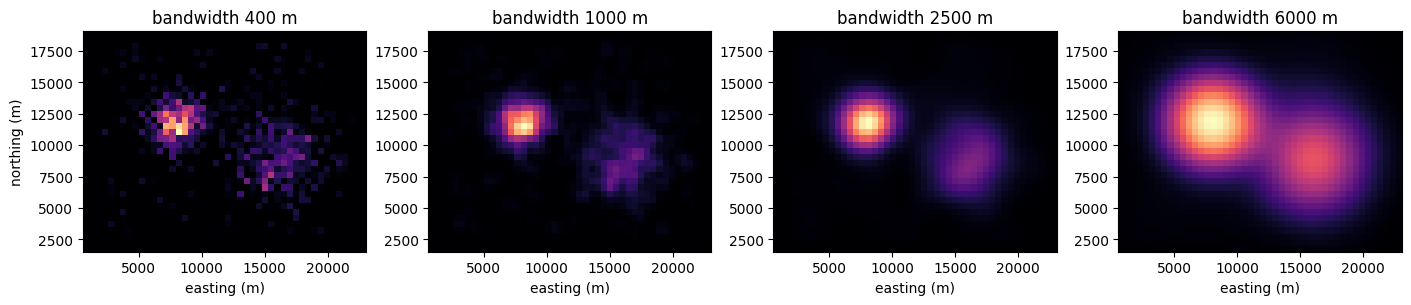

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(14, 3.4), constrained_layout=True)

for ax, h in zip(axes, [400.0, 1_000.0, 2_500.0, 6_000.0]):

    field = density_field(hypocentres, grid["origin"], grid["spacing"],
                          grid["counts"], [h] * 3).reshape(grid["counts"], order="F")

    # Sum through depth: a map of hypocentres per unit area, so the four
    # panels are on one scale whatever the bandwidth does to the peak.
    column = field.sum(axis=2) * grid["spacing"][2]

    ax.imshow(column.T, origin="lower", extent=extent, cmap="magma")
    ax.set_title(f"bandwidth {h:.0f} m")
    ax.set_xlabel("easting (m)")

axes[0].set_ylabel("northing (m)")
plt.show()

At 400 m you are looking at the individual events. At 6 km the two
clusters have become one blob straddling ground that has almost nothing in it.
Somewhere in between is an honest picture, and choosing where is a judgement
about the scale of the process you are trying to see — not something to be
optimised out of the data.

## One bandwidth per axis

Depth is not interchangeable with easting, even when both are in metres. A
seismogenic layer is tens of kilometres wide and a few thick, so an isotropic
kernel wide enough to smooth along strike will mix the top of the layer with
the bottom before it mixes two neighbouring events.

`bandwidth` therefore takes one number per axis.

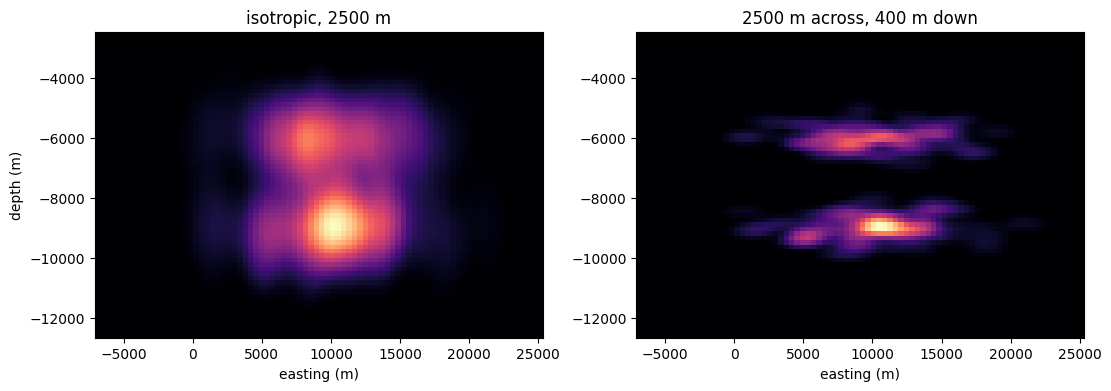

In [6]:
# Two levels of seismicity under the same map footprint, 3 km apart in
# depth and each only ~400 m thick. Exactly the geometry an isotropic kernel
# cannot see.
layered = np.vstack([
    rng.normal([10_000, 10_000,  -6_000], [4_000, 4_000, 400], size=(350, 3)),
    rng.normal([10_000, 10_000,  -9_000], [4_000, 4_000, 400], size=(350, 3)),
])

layer_grid = covering_grid(layered, spacing=[400.0, 400.0, 150.0], margin=2_500.0)
layer_depths = (layer_grid["origin"][2]
                + np.arange(layer_grid["counts"][2]) * layer_grid["spacing"][2])
mid_row = layer_grid["counts"][1] // 2

def section(bandwidth):
    field = density_field(layered, layer_grid["origin"], layer_grid["spacing"],
                          layer_grid["counts"], bandwidth)
    return field.reshape(layer_grid["counts"], order="F")[:, mid_row, :]

section_extent = [
    layer_grid["origin"][0],
    layer_grid["origin"][0] + (layer_grid["counts"][0] - 1) * layer_grid["spacing"][0],
    layer_depths[0], layer_depths[-1],
]

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), constrained_layout=True)
for ax, bandwidth, title in [
    (axes[0], [2_500.0] * 3, "isotropic, 2500 m"),
    (axes[1], [2_500.0, 2_500.0, 400.0], "2500 m across, 400 m down"),
]:
    ax.imshow(section(bandwidth).T, origin="lower", extent=section_extent,
              aspect="auto", cmap="magma")
    ax.set_title(title)
    ax.set_xlabel("easting (m)")
axes[0].set_ylabel("depth (m)")
plt.show()

The right-hand panel shows two thin, distinct levels. The left-hand one
shows a single body six kilometres thick with two faint maxima inside it,
because 2.5 km of vertical smoothing is comparable with the 3 km gap it was
asked to resolve. A reader of that panel would report one seismogenic volume
where the data say two layers a few hundred metres thick each.

The map bandwidth is identical in both. Only the depth one changed.

## Kernel shapes, and what reach costs

Three shapes are on offer, and the difference that matters between them is not
smoothness but **reach** — how far one observation is felt.

- `quartic` (the default) is `(1 - u²)²` inside one bandwidth and exactly zero
  outside. Compact by construction, so nothing is thrown away and the integral
  is exactly one.
- `truncated_gaussian` is a Gaussian cut off at so many bandwidths and **not**
  renormalized: the tail beyond the cut is simply missing, and
  `retained_mass` tells you how much.
- `gaussian` never reaches zero. Correct, occasionally what you want, and the
  one to use when checking against another implementation that did the same —
  but it means every node is a sum over the entire dataset.

`kernel_profile` reports all of this before you run anything.

In [7]:
shapes = [("quartic", 1.0), ("gaussian", 1.0),
          ("truncated_gaussian", 2.0), ("truncated_gaussian", 3.0),
          ("truncated_gaussian", 4.0)]

for shape, cut in shapes:

    profile = kernel_profile([BANDWIDTH] * 3, kernel=shape, truncation=cut)

    label = shape if shape != "truncated_gaussian" else f"{shape} at {cut:.0f}"
    reach = "unbounded" if profile["reach"] is None else f"{profile['reach'][0]:8.0f} m"

    print(f"{label:26} reach {reach}   keeps {profile['retained_mass'] * 100:7.3f}%"
          f"   peak {profile['peak']:.3e}")

quartic                    reach     1500 m   keeps 100.000%   peak 3.095e-10
gaussian                   reach unbounded   keeps 100.000%   peak 1.881e-11
truncated_gaussian at 2    reach     3000 m   keeps  73.854%   peak 1.881e-11
truncated_gaussian at 3    reach     4500 m   keeps  97.071%   peak 1.881e-11
truncated_gaussian at 4    reach     6000 m   keeps  99.887%   peak 1.881e-11


Cutting a three-dimensional Gaussian at three bandwidths throws away
almost 3% of it; at four, about a tenth of a percent. And the reach is what the
neighbour search bins on, so it is also what the run costs:

In [8]:
import time

def timed(**kwargs):
    start = time.perf_counter()
    field = density_field(hypocentres, grid["origin"], grid["spacing"],
                          grid["counts"], [BANDWIDTH] * 3, **kwargs)
    return time.perf_counter() - start, field

for kwargs in [dict(kernel="quartic"),
               dict(kernel="truncated_gaussian", truncation=4.0),
               dict(kernel="gaussian")]:

    seconds, field = timed(**kwargs)
    name = kwargs["kernel"] + (f" at {kwargs['truncation']:.0f}" if "truncation" in kwargs else "")
    print(f"{name:26} {seconds * 1000:8.1f} ms    integrates to {field.sum() * cell_volume:7.2f}")

print()
print(f"{len(hypocentres)} observations x {grid['node_count']} nodes ="
      f" {len(hypocentres) * grid['node_count'] / 1e6:.0f} million pairs,"
      f" which is what the unbounded kernel evaluates")

quartic                        10.2 ms    integrates to  850.11
truncated_gaussian at 4        54.6 ms    integrates to  833.62


gaussian                      145.8 ms    integrates to  834.36

850 observations x 49680 nodes = 42 million pairs, which is what the unbounded kernel evaluates


The unbounded Gaussian is an order of magnitude slower for the same
answer, because it evaluates every one of those pairs. A compact kernel visits
only the neighbourhood of each node. That difference is what makes a fine grid
affordable, and it is why `quartic` is the default.

**But look at the integrals.** The quartic recovers all 850; both Gaussians
come back around 834. The plain Gaussian keeps every bit of its mass —
`retained_mass` said 1.0 — so where did sixteen events go?

Off the edge of the grid. The margin was set to one bandwidth, which is exactly
right for the quartic, whose reach *is* one bandwidth: every kernel is fully
inside the grid and nothing is lost. A Gaussian at the same bandwidth is still
appreciable four bandwidths out, so for every observation near the boundary a
slice of its kernel falls outside the nodes and is never summed.

The lesson is that **the margin has to match the kernel's reach, not the
bandwidth**. `kernel_profile` reports that reach precisely so you can set one
from the other. The remaining difference between the two Gaussians — about
three-quarters of an event — is the truncation itself, and matches
`retained_mass` for a cut at four. That loss is reported and not corrected for:
a density short by a known thousandth is easier to reason about than one
silently rescaled, and if you want it back you can divide.

Which is a claim worth testing rather than believing:

In [9]:
for margin in [BANDWIDTH, 4 * BANDWIDTH]:

    wider = covering_grid(hypocentres, [500.0, 500.0, 500.0], margin)
    field = density_field(hypocentres, wider["origin"], wider["spacing"],
                          wider["counts"], [BANDWIDTH] * 3, kernel="gaussian")

    total = field.sum() * float(np.prod(wider["spacing"]))
    print(f"margin {margin:6.0f} m ({margin / BANDWIDTH:.0f} bandwidths), "
          f"{wider['node_count']:7d} nodes -> integrates to {total:7.2f}")

margin   1500 m (1 bandwidths),   49680 nodes -> integrates to  834.36


margin   6000 m (4 bandwidths),  165888 nodes -> integrates to  850.00


Four bandwidths of margin and the Gaussian recovers the count too — at
the price of a grid with a good deal more empty space around the edges. Which
is the trade a compact kernel avoids having to make.

## One dimension: depths without bins

A histogram of hypocentral depths is a one-dimensional density, and estimating
it with a kernel rather than with bins gets rid of the two things wrong with a
histogram: the edges have to be chosen by hand, and the answer changes when
they move.

The same call does it. Pass an `(N, 1)` array.

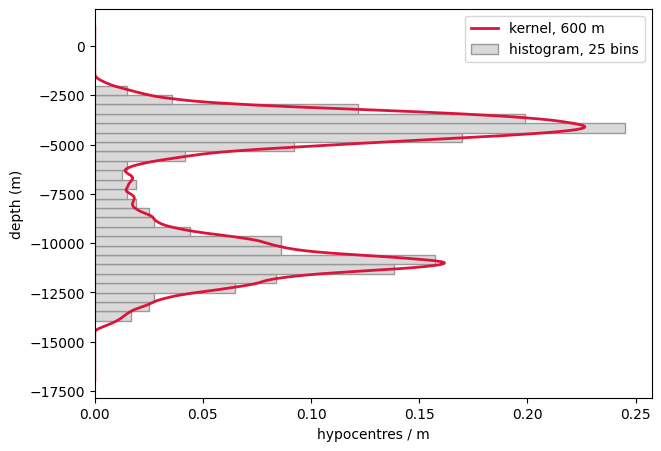

integrates to 849.9999809738559 of 850


In [10]:
depth_column = hypocentres[:, 2:3]          # (N, 1), not (N,)

profile_grid = covering_grid(depth_column, spacing=[50.0], margin=3_000.0)
by_depth = density_field(depth_column, profile_grid["origin"], profile_grid["spacing"],
                         profile_grid["counts"], [600.0])

z = (np.array(profile_grid["origin"])[0]
     + np.arange(profile_grid["counts"][0]) * profile_grid["spacing"][0])

# The histogram in the same units as the kernel -- hypocentres per metre --
# rather than normalized to one, or the two would be plotted 850 apart and
# only one of them would be visible.
tally, edges = np.histogram(hypocentres[:, 2], bins=25)
widths = np.diff(edges)

fig, ax = plt.subplots(figsize=(6.5, 4.4), constrained_layout=True)
ax.barh(edges[:-1], tally / widths, height=widths, align="edge",
        color="0.85", edgecolor="0.6", label="histogram, 25 bins")
ax.plot(by_depth, z, lw=2, color="crimson", label="kernel, 600 m")
ax.set_xlabel("hypocentres / m")
ax.set_ylabel("depth (m)")
ax.legend()
plt.show()

print("integrates to", by_depth.sum() * profile_grid["spacing"][0],
      "of", len(depth_column))

Both are in the same units — hypocentres per metre — so they are directly
comparable, and the kernel integrates to 850 like everything else here.

The histogram is not wrong, it is just answering a slightly different question,
and the two ways it can mislead are visible in the picture: its steps put edges
where the data have none, and every one of those edges was chosen by whoever
picked `bins=25`. Move them half a bin and the two peaks change height. The
kernel estimate has one free choice instead — the bandwidth — and that choice
is a statement about the scale of the process rather than about where a
boundary happens to fall.

## What to carry away

- The field is **observations per unit volume**, and it integrates back to the
  count. Check that; it is one line and it catches the failure this family of
  code is prone to.
- `origin` is the **first node**. There is no half cell anywhere.
- The result is **flat, first axis fastest**. Reshape with `order="F"`.
- **Bandwidth is in map units, one per axis**, and it is your decision.
- Prefer a **compact kernel**. `quartic` reaches one bandwidth,
  `truncated_gaussian` at 4 keeps 99.9% and reaches four; plain `gaussian`
  reaches everywhere and costs accordingly.

The companion notebook, `02_stress_field.ipynb`, takes the same machinery and
inverts a stress tensor at every node of a grid — where the density stops being
the answer and becomes the thing you have to read *beside* the answer.